<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install shap

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import shap
import warnings
warnings.filterwarnings('ignore')

In [22]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df  = pd.read_csv(url)

print("HEART DISEASE DATASET INFO")
print(f"Columns         : {list(df.columns)}")

HEART DISEASE DATASET INFO
Columns         : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [23]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [24]:
X = df.drop('target', axis=1).values
y = df['target'].values

feature_names = list(df.drop('target', axis=1).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to DataFrame for SHAP plots
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
X_train_df = pd.DataFrame(X_train, columns=feature_names)

print(f"\nTrain samples  : {X_train.shape[0]}")
print(f"Test samples   : {X_test.shape[0]}")


Train samples  : 242
Test samples   : 61


In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',
                          input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("\nTraining MLP Model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Training MLP Model...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5285 - loss: 0.7287 - val_accuracy: 0.4898 - val_loss: 0.6974
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5233 - loss: 0.6910 - val_accuracy: 0.5918 - val_loss: 0.6379
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5699 - loss: 0.6335 - val_accuracy: 0.6939 - val_loss: 0.5957
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6373 - loss: 0.6099 - val_accuracy: 0.7347 - val_loss: 0.5641
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6684 - loss: 0.5896 - val_accuracy: 0.7347 - val_loss: 0.5382
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7254 - loss: 0.5622 - val_accuracy: 0.7347 - val_loss: 0.5182
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7358 - loss: 0.5521 - val_accuracy: 0.7143 - val_loss: 0.5012
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8135 - loss: 0.4852 - val_accur

In [32]:
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
accuracy    = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy  : {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Heart Disease']))


Test Accuracy  : 83.61%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.81      0.86      0.83        29
Heart Disease       0.87      0.81      0.84        32

     accuracy                           0.84        61
    macro avg       0.84      0.84      0.84        61
 weighted avg       0.84      0.84      0.84        61




Evaluating MLP Model on Test Data...
Test Loss: 0.5598
Test Accuracy: 0.8361


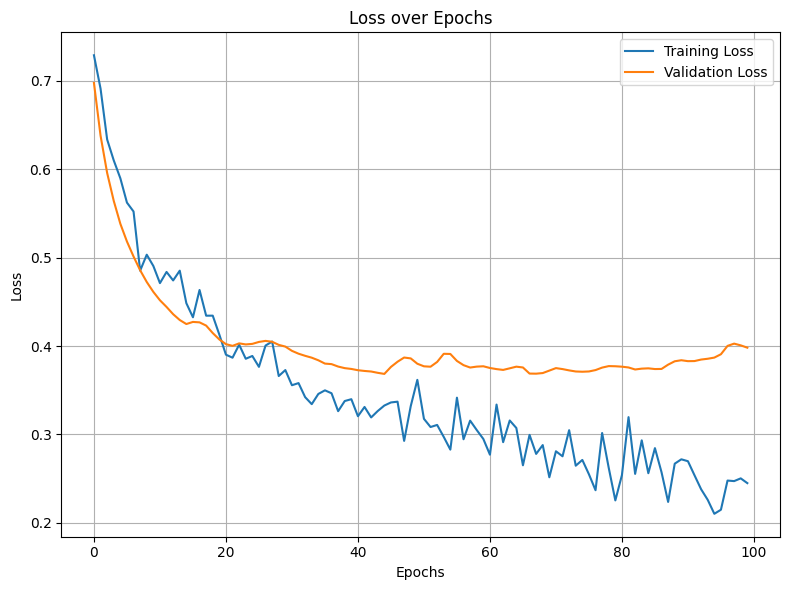

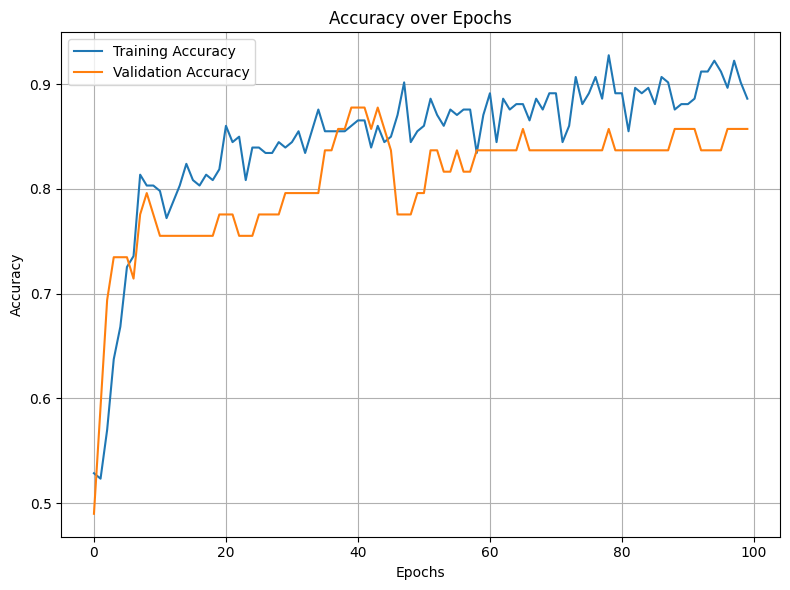

In [27]:
print("\nEvaluating MLP Model on Test Data...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

test_loss = loss
test_accuracy = accuracy


plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
print("\nComputing SHAP Values...")

# Wrap model for SHAP
def model_predict(X):
    return model.predict(X, verbose=0).flatten()

# Use KernelExplainer (works with any black-box model)
# Use small background dataset (50 samples) for speed
background  = X_train[:50]
explainer   = shap.KernelExplainer(model_predict, background)

# Compute SHAP values for test set (use first 50 for speed)
shap_values = explainer.shap_values(X_test[:50], nsamples=100)

print(f"SHAP Values Shape : {np.array(shap_values).shape}")
print("SHAP Values Computed Successfully!")


Computing SHAP Values...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP Values Shape : (50, 13)
SHAP Values Computed Successfully!



Plotting SHAP Summary Plot (Global)...


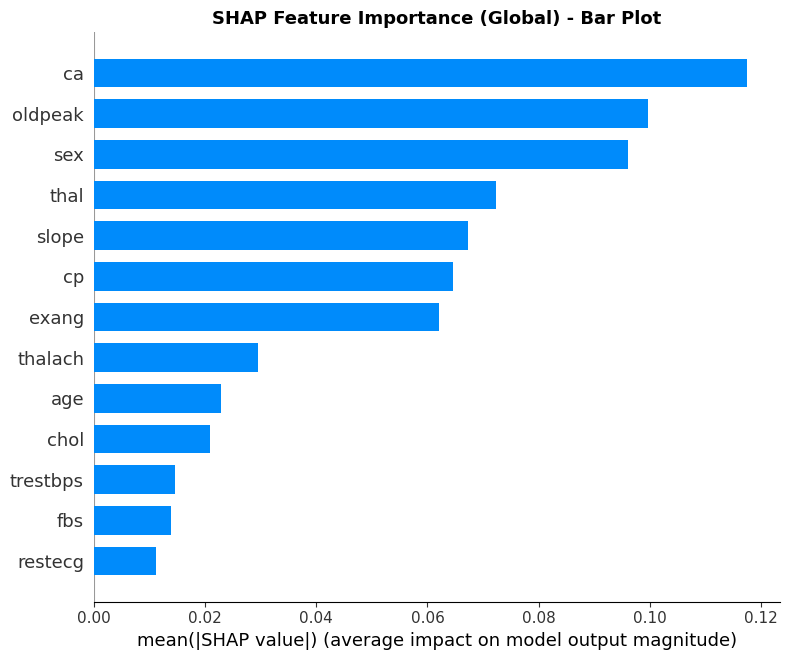

In [35]:
print("\nPlotting SHAP Summary Plot (Global)...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=feature_names,
    plot_type='bar',           # Bar chart = global importance
    show=False
)
plt.title('SHAP Feature Importance (Global) - Bar Plot',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Plotting SHAP Beeswarm Plot...


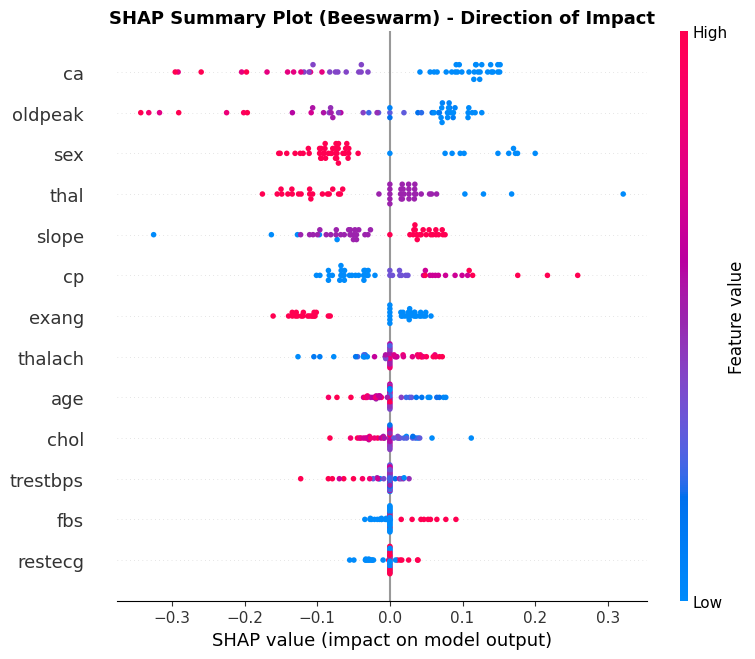

In [36]:
print("Plotting SHAP Beeswarm Plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=feature_names,
    plot_type='dot',           # Dot/Beeswarm = direction of impact
    show=False
)
plt.title('SHAP Summary Plot (Beeswarm) - Direction of Impact',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


Generating SHAP Force Plot for Sample 0...

Sample 0 Details:
  True Label  : No Disease
  Prediction  : No Disease
  Probability : 0.0498


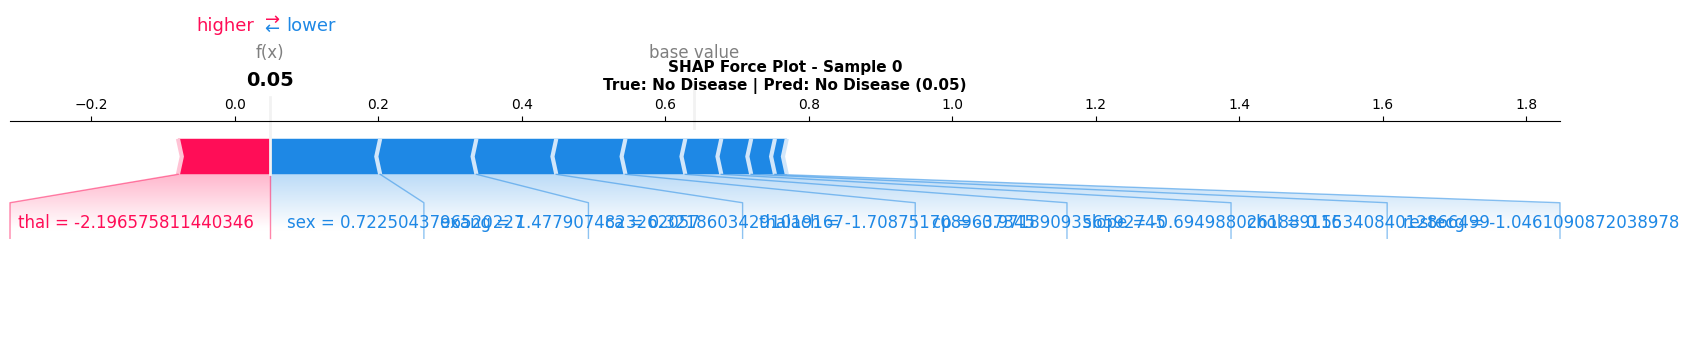

In [38]:
print("\nGenerating SHAP Force Plot for Sample 0...")

# Sample 0
sample_idx   = 0
sample       = X_test[sample_idx]
true_label   = y_test[sample_idx]
pred_prob    = y_pred_prob[sample_idx]
pred_label   = y_pred[sample_idx]

print(f"\nSample {sample_idx} Details:")
print(f"  True Label  : {'Heart Disease' if true_label==1 else 'No Disease'}")
print(f"  Prediction  : {'Heart Disease' if pred_label==1 else 'No Disease'}")
print(f"  Probability : {pred_prob:.4f}")

# Force plot (saved as matplotlib)
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test[sample_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - Sample {sample_idx}\n'
          f'True: {"Heart Disease" if true_label==1 else "No Disease"} | '
          f'Pred: {"Heart Disease" if pred_label==1 else "No Disease"} '
          f'({pred_prob:.2f})',
          fontweight='bold', fontsize=11)
plt.show()